In [2]:
import numpy as np 
import os
import sys
# from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
sns.set_theme()

from shapely import box
import geopandas as gpd

# ====== import my own functions =========
import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from layers import assemble_data
from validation import validate_date_pairs

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data assembly 

Start by identifying the location of the data (there are two inputs required) and the location of the shapefile for the area of interest. 

In [ ]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/' # on Borah 
data_dir = '../data/'# on local machine 

mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
mcs_aoi

,id,geometry
0,1,"POLYGON ((-115.6739 43.98328, -115.67315 43.98..."


I just hard coded the dates for the flights that cover MCS from flight path 05208. These need to match the dates in the filenames of the coherence files. 

In [1]:
mcs_lowman_05208_dates = ['200131_200213',
 '200131_200220',
 '200131_200311',
 '200131_210203',
 '200131_210210',
 '200131_210303',
 '200131_210310',
 '200131_210316',
 '200131_210322',
 '200213_200220',
 '200213_200311',
 '200213_210203',
 '200213_210210',
 '200213_210303',
 '200213_210310',
 '200213_210316',
 '200213_210322',
 '200220_200311',
 '200220_210203',
 '200220_210210',
 '200220_210303',
 '200220_210310',
 '200220_210316',
 '200220_210322',
 '200311_210203',
 '200311_210210',
 '200311_210303',
 '200311_210310',
 '200311_210316',
 '200311_210322',
 '210203_210210',
 '210203_210303',
 '210203_210310',
 '210203_210316',
 '210203_210322',
 '210210_210303',
 '210210_210310',
 '210210_210316',
 '210210_210322',
 '210303_210310',
 '210303_210316',
 '210303_210322',
 '210310_210316',
 '210310_210322',
 '210316_210322']

split_dates = [(part[0], part[1]) for part in [d.split('_') for d in mcs_lowman_05208_dates]]
# go from YYMMDD to YYYYMMDD
split_dates = [(f"20{date[0]}", f"20{date[1]}") for date in split_dates]

In [ ]:
aoi = box(*mcs_aoi.total_bounds) # using the total bounds to get some buffer 
# test_dates = [("20200101", "20200113"), 
#          ("20200101", "20200129"),
#          ("20200113", "20200129"),
#          ("20210202", "20210214")]
dates_val = validate_date_pairs(split_dates)
fp_out = data_dir + 'stacks/mores_creek'
coh_dir = '/Users/JULIALOBER/snowex_uavsar_coherence/data/coherence/mcs/'

This function requires two things be downloaded and ready: 
1. The Snow Climatology from NSIDC 

    filename: `SnowClass_NA_300m_10.0arcsec_2021_v01.0.nc`

2. Geocoded coherence files

    filename: `[...]_YYMMDD_YYMMDD_[...].?`

In [5]:
data = assemble_data(aoi,
                    dates_val,
                    fp_out,
                    fp_coherence=coh_dir,
                    overwrite = True)
data

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


Got NLCD ['cover_2019', 'canopy_2019'] in 1.646 seconds.
Got DEM in 2.302 seconds.
Got topo layers: ['slope', 'aspect', 'curve'] in 0.416 seconds.
Got snow climatology: ['snow_class'] in 5.581 seconds.
Got AORC: ['mean_temp', 'max_temp', 'total_precip'] in 11.149 seconds.


QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 617.95it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  2.28it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 83055.52it/s]


Got SWE layers: ['swe_change', 'sd_change'] in 38.165 seconds.


/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


<xarray.Dataset> Size: 858kB
Dimensions:       (pair: 45, x: 26, y: 20)
Coordinates:
  * pair          (pair) <U13 2kB '200131_200213' ... '210316_210322'
  * x             (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y             (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
    band          int64 8B 1
    spatial_ref   int64 8B 0
    crs           int64 8B 0
Data variables: (12/13)
    coherence     (pair, y, x) float32 94kB nan nan nan nan ... nan nan nan nan
    cover_2019    (y, x) uint8 520B 52 52 71 71 52 42 42 ... 52 42 42 52 52 52
    canopy_2019   (y, x) float32 2kB 0.0 0.0 0.0 11.0 ... 69.0 12.0 19.0 0.0
    elevation     (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope         (y, x) float32 2kB 9.666 13.45 3.886 ... 21.88 20.76 23.85
    aspect        (y, x) float32 2kB 206.5 198.5 125.0 ... 37.39 35.99 27.13
    ...            ...
    snow_class    (y, x) float32 2kB 1.0 2.0 1.0 5.0 6.0 ... 6.0 6.0 6.0 5.0 5.0
    swe_change    (pair, y, x) float32 94kB 0.1132 0.0932 ... -0.0092 0.0116
    sd_change     (pair, y, x) float32 94kB 0.099 0.1566 ... -0.0704 0.0554
    mean_temp     (pair, y, x) float64 187kB 0.1808 0.1796 0.1796 ... nan nan
    max_temp      (pair, y, x) float64 187kB 7.4 7.8 7.8 8.2 ... nan nan nan nan
    total_precip  (pair, y, x) float64 187kB 56.6 56.2 56.2 57.0 ... nan nan nan

In [14]:
print(data)

<xarray.Dataset> Size: 858kB
Dimensions:       (pair: 45, x: 26, y: 20)
Coordinates:
  * pair          (pair) <U13 2kB '200131_200213' ... '210316_210322'
  * x             (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y             (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
    band          int64 8B 1
    spatial_ref   int64 8B 0
    crs           int64 8B 0
Data variables: (12/13)
    coherence     (pair, y, x) float32 94kB nan nan nan nan ... nan nan nan nan
    cover_2019    (y, x) uint8 520B 52 52 71 71 52 42 42 ... 52 42 42 52 52 52
    canopy_2019   (y, x) float32 2kB 0.0 0.0 0.0 11.0 ... 69.0 12.0 19.0 0.0
    elevation     (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope         (y, x) float32 2kB 9.666 13.45 3.886 ... 21.88 20.76 23.85
    aspect        (y, x) float32 2kB 206.5 198.5 125.0 ... 37.39 35.99 27.13
    ...            ...
    snow_class    (y, x) float32 2kB 1.0 2.0 1.0 5.0 6.0 ... 6.0 6.0 6.0 5.0 5

In [ ]:
n = len(data)
fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize = (10, 6))
axes = axes.flatten()

for i, var in enumerate(data.data_vars): 
    # print(var, i)
    # print(data[var])
    data[var].plot(ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    if 'pair' in data[var].dims:
        axes[i].set_visible(False)  # hide the placeholder axis in the main grid
        data[var].plot(
            col='pair',
            col_wrap=3,
            figsize=(10, 3 * int(np.ceil(data.sizes['pair'] / 3)))
        )
        plt.suptitle(var, y=1.02)
        # plt.tight_layout()
        # plt.show()
    # break

plt.tight_layout()
plt.show()

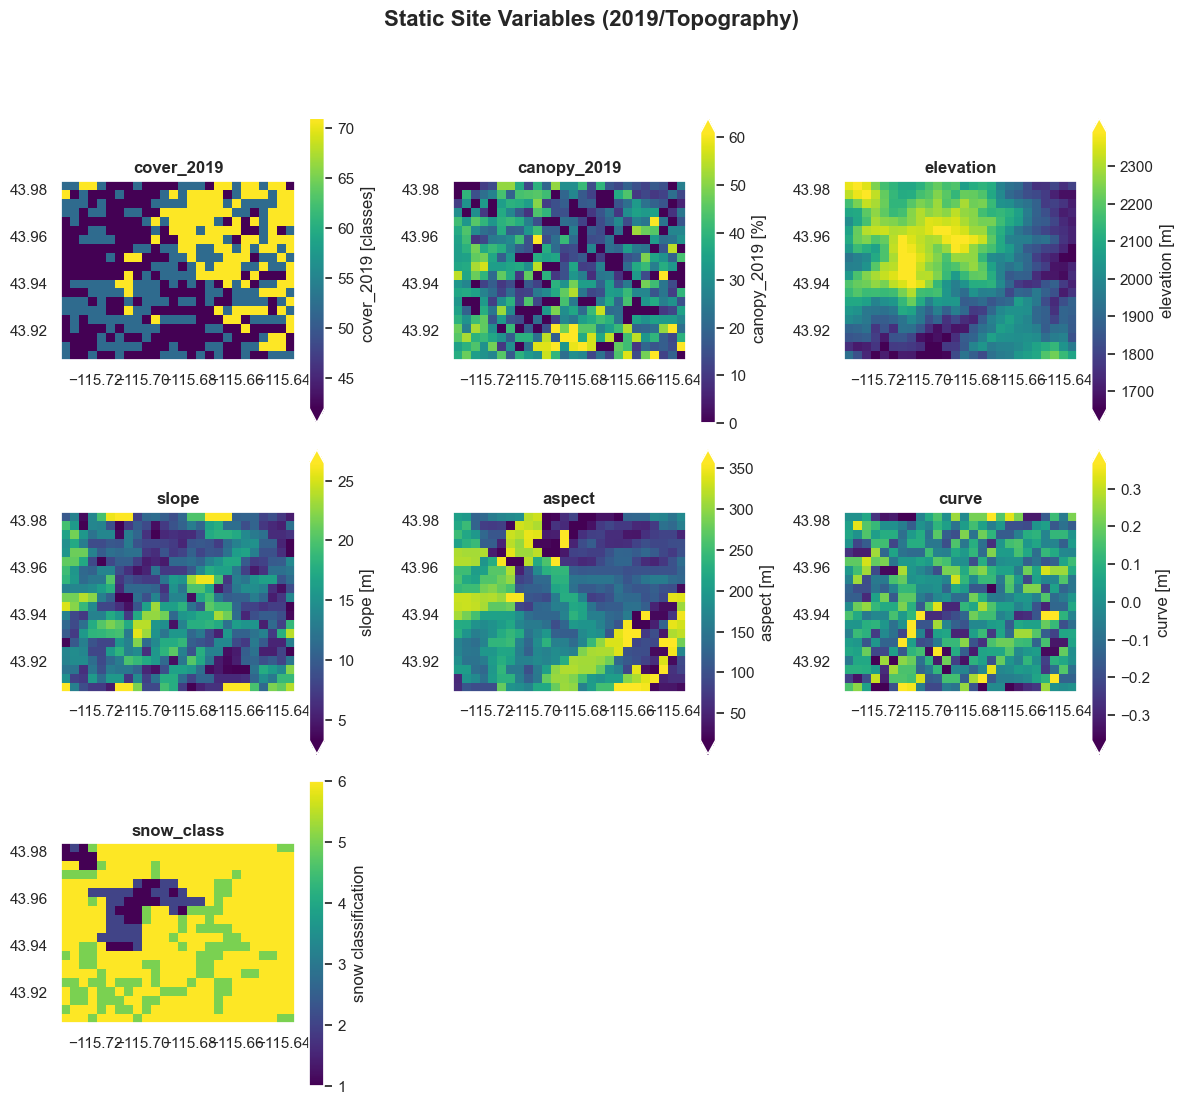

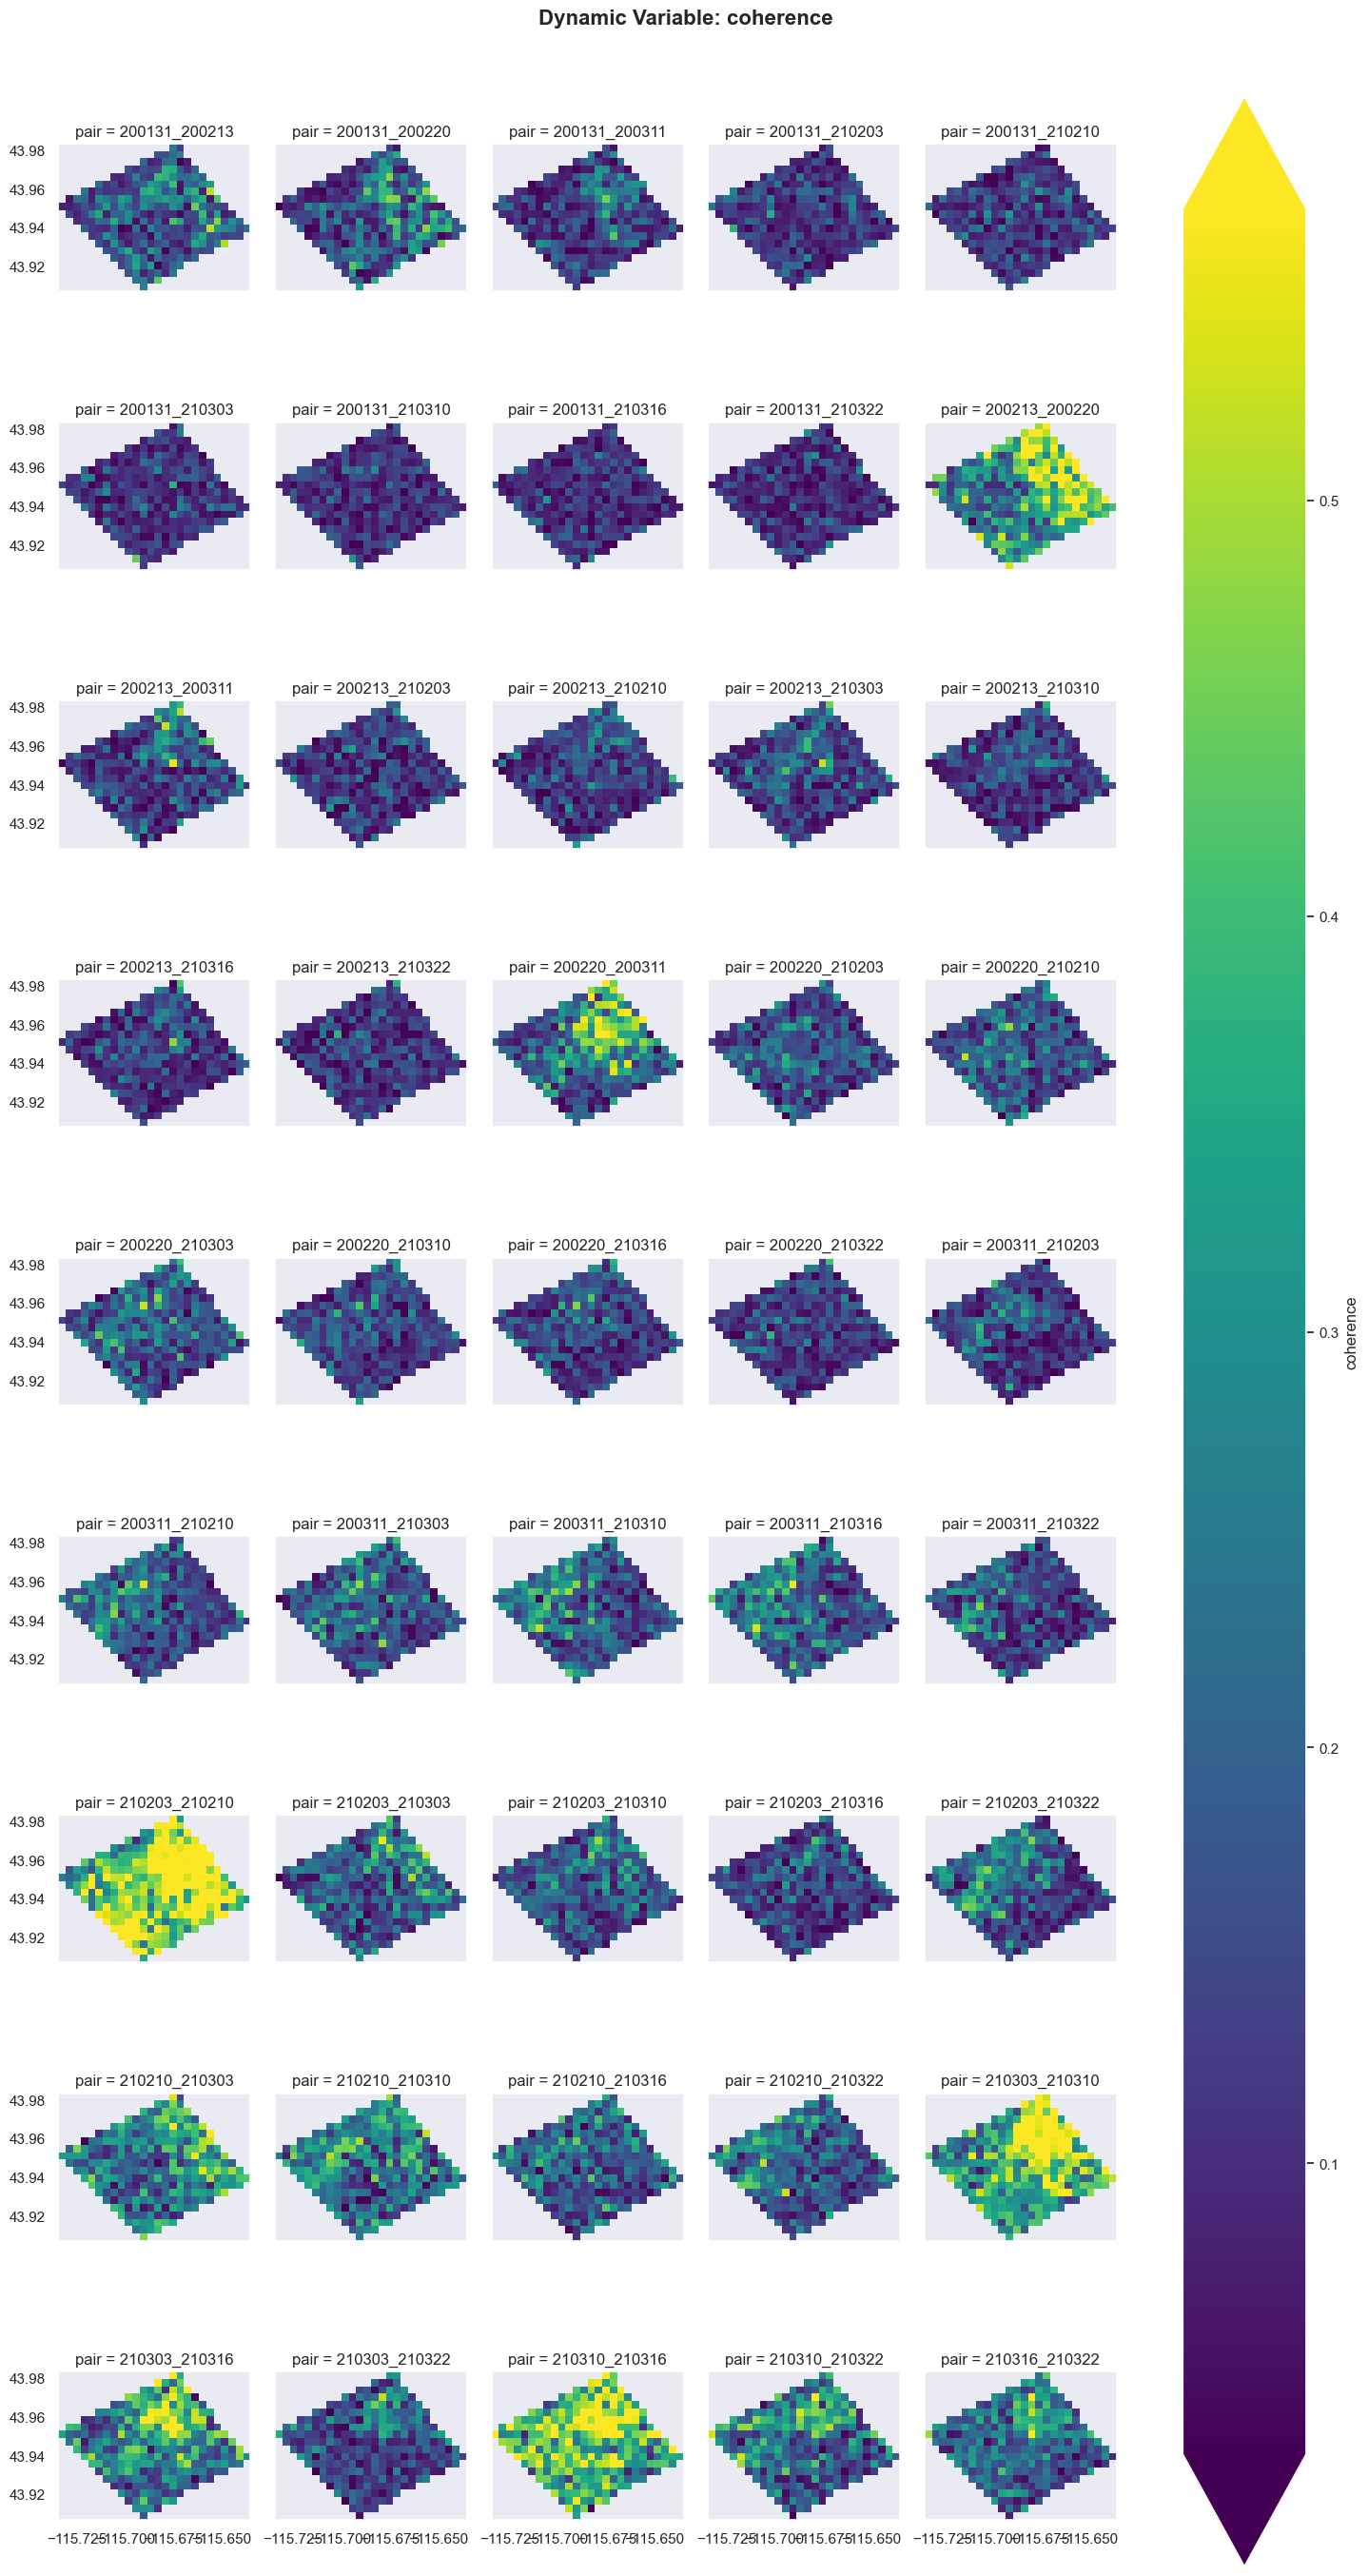

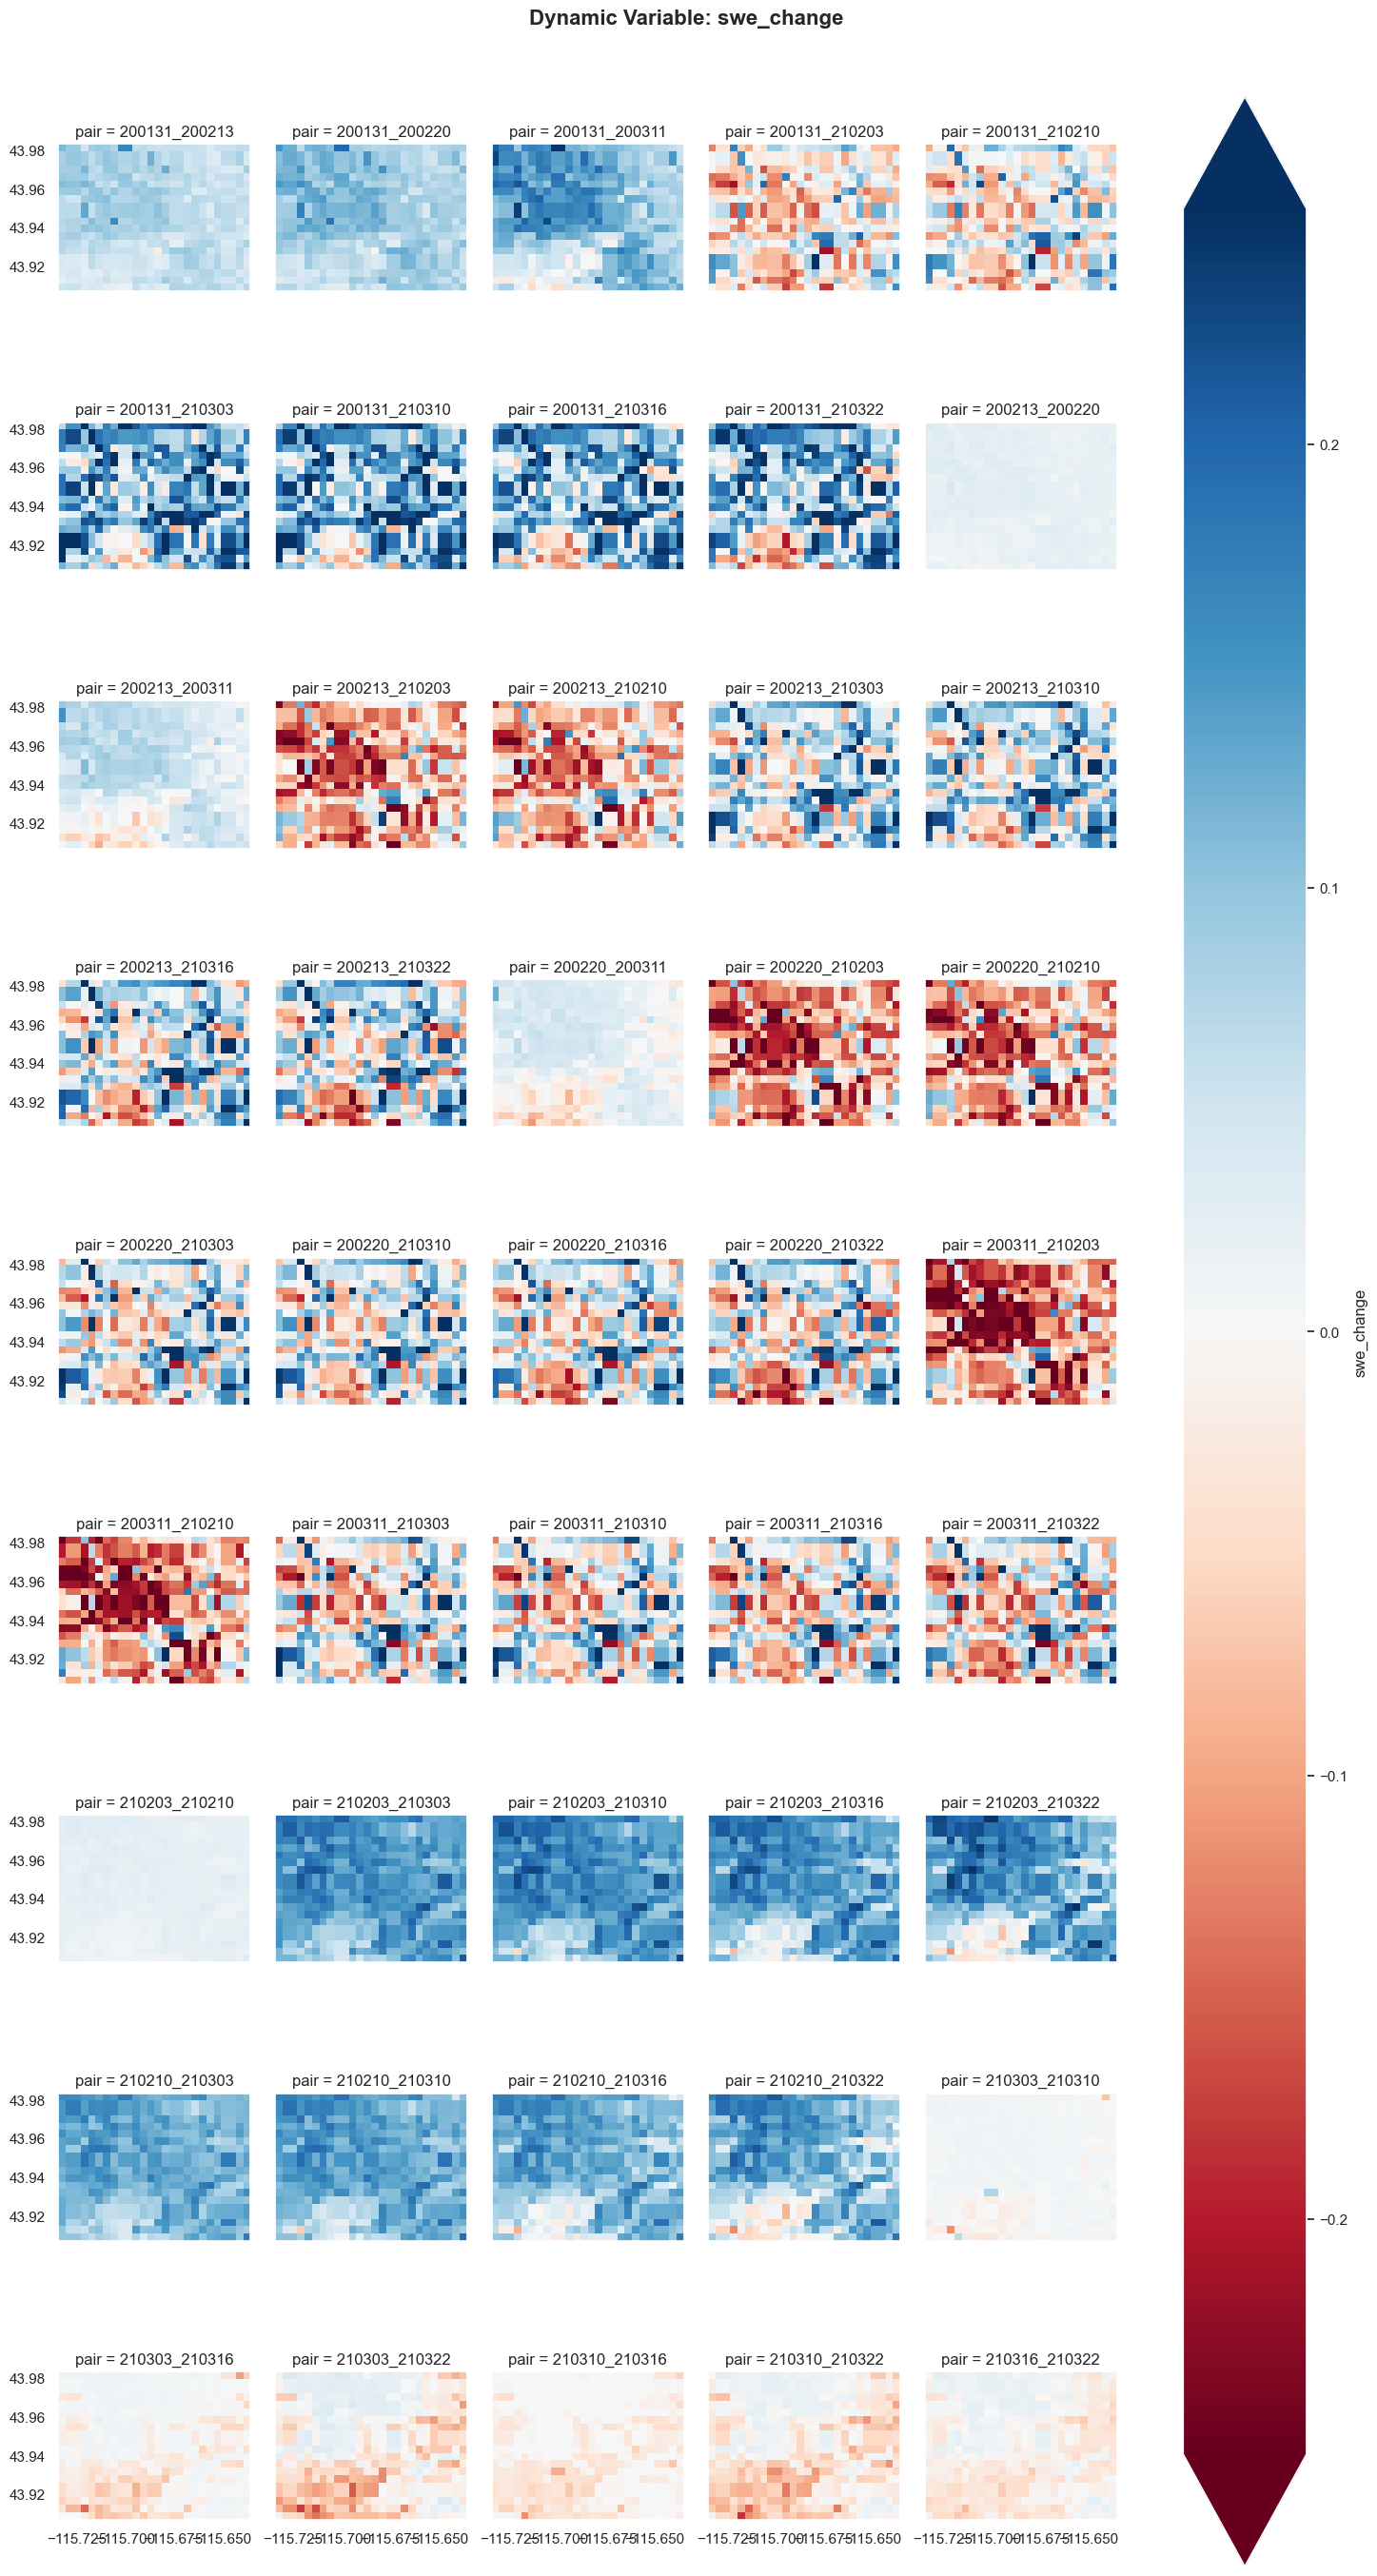

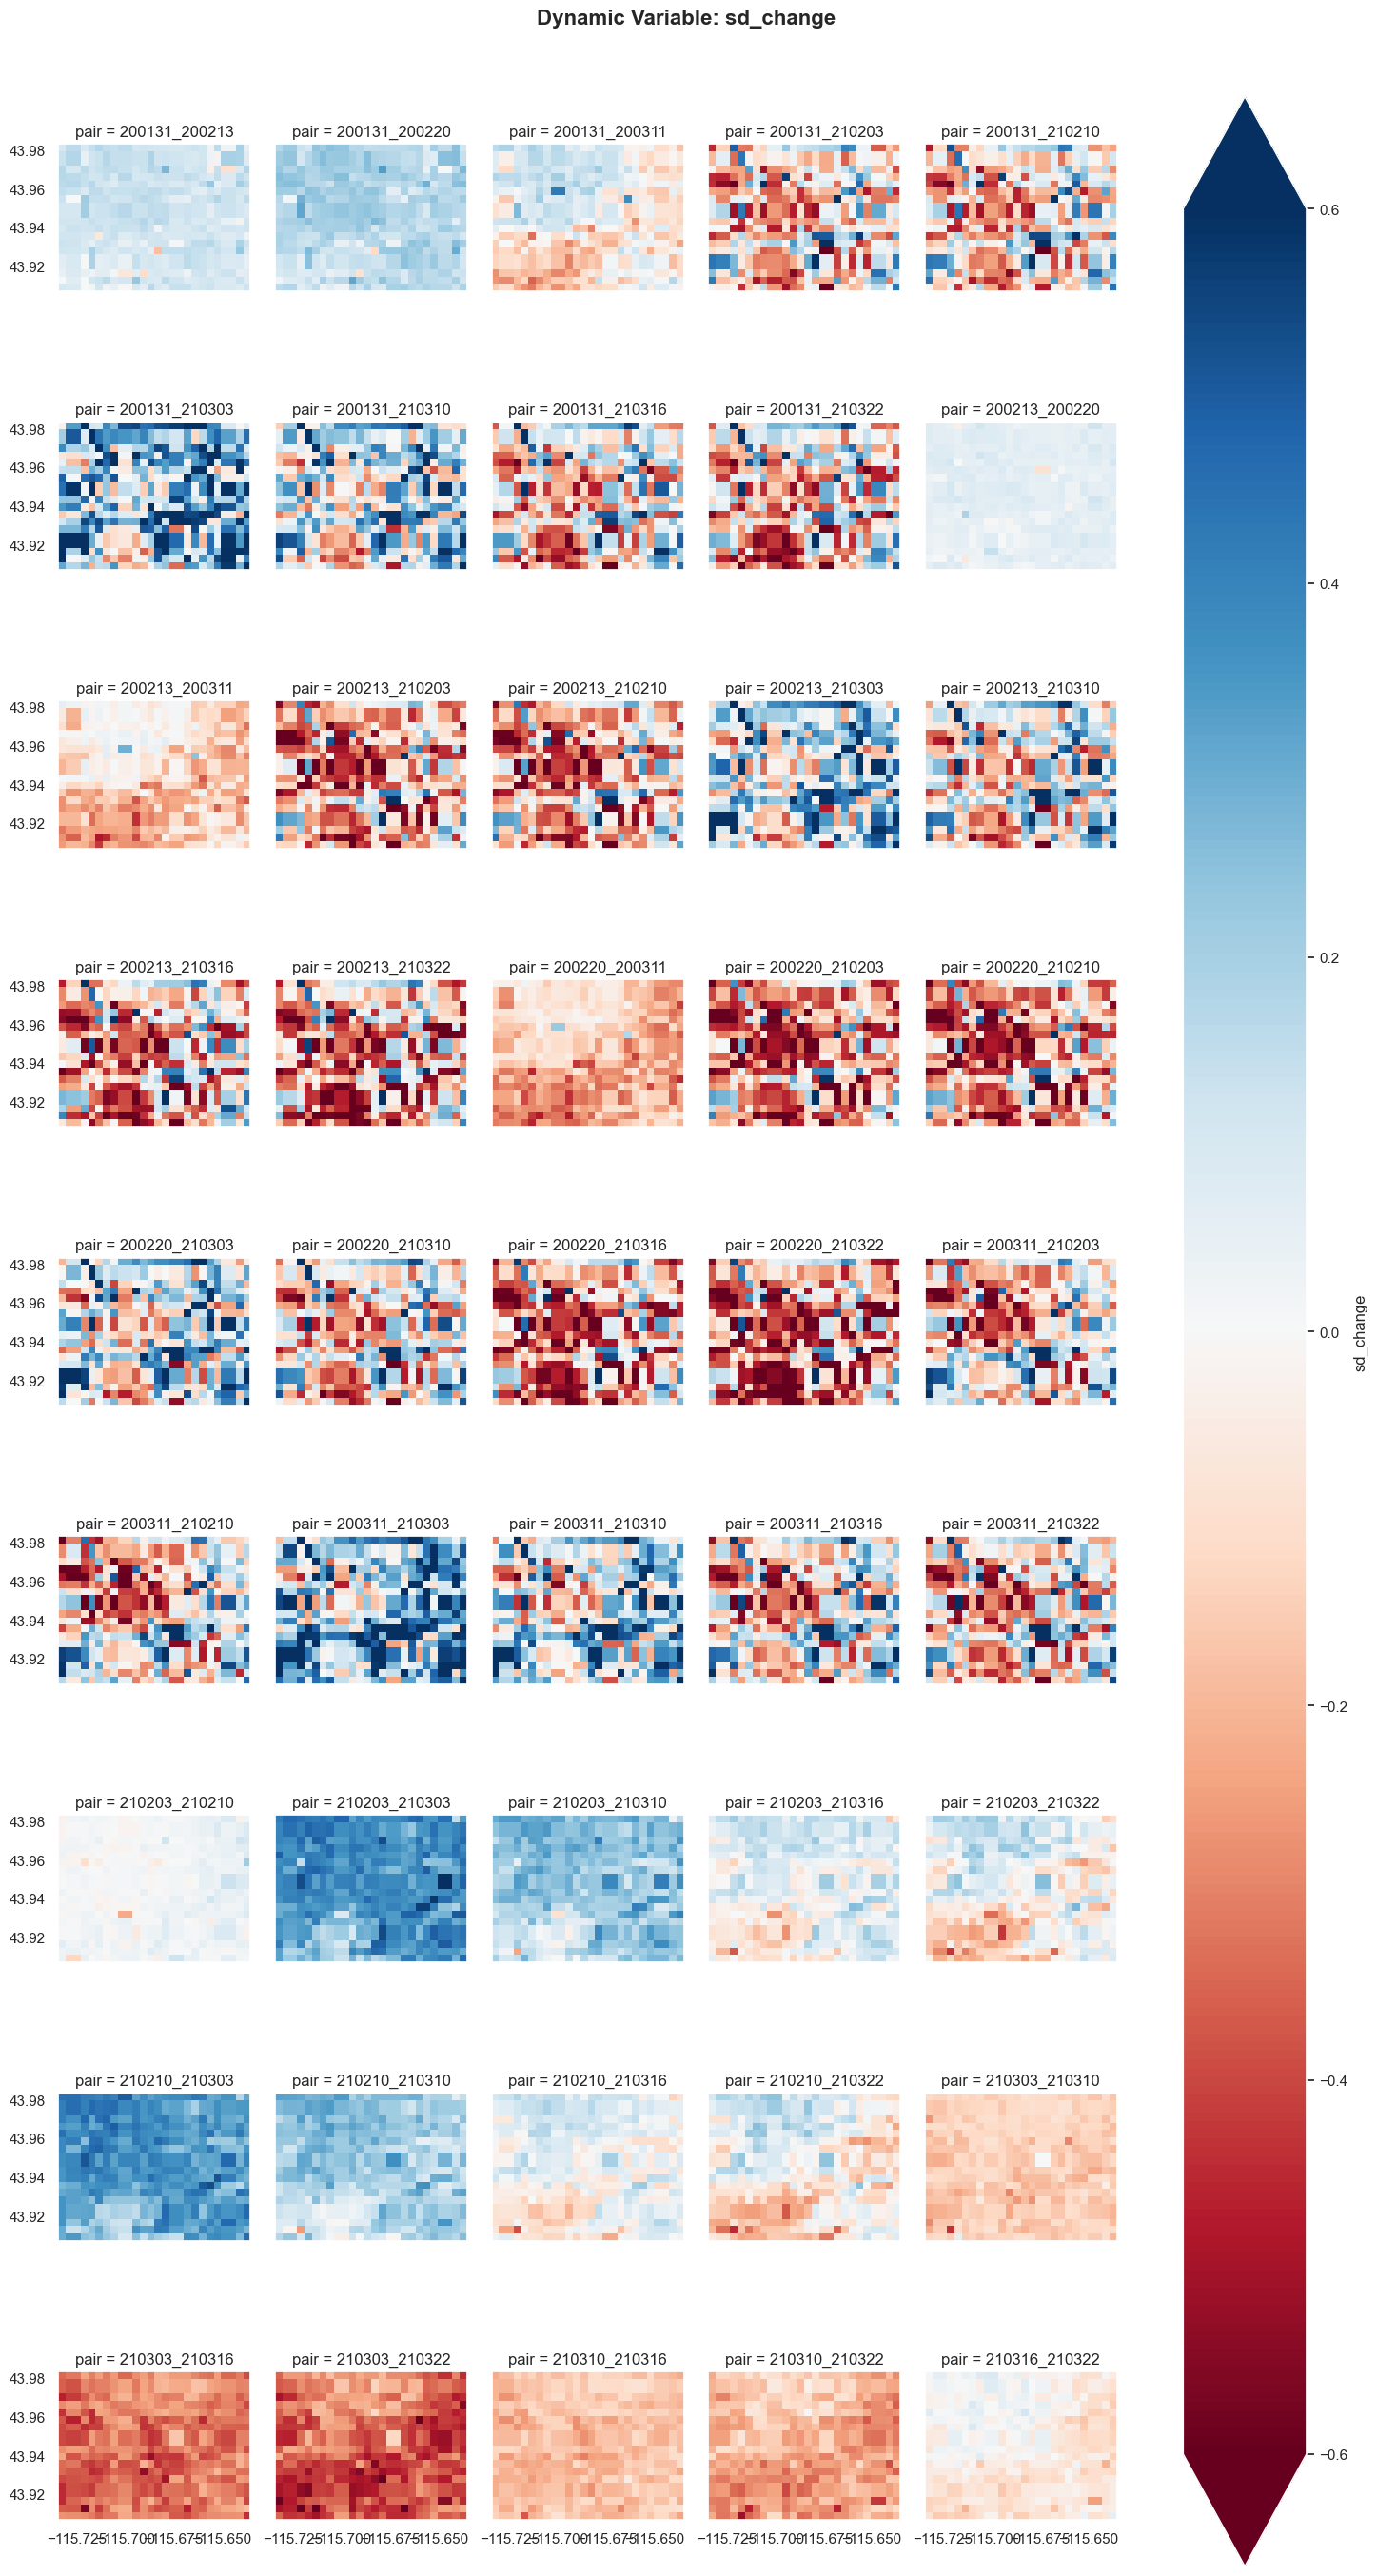

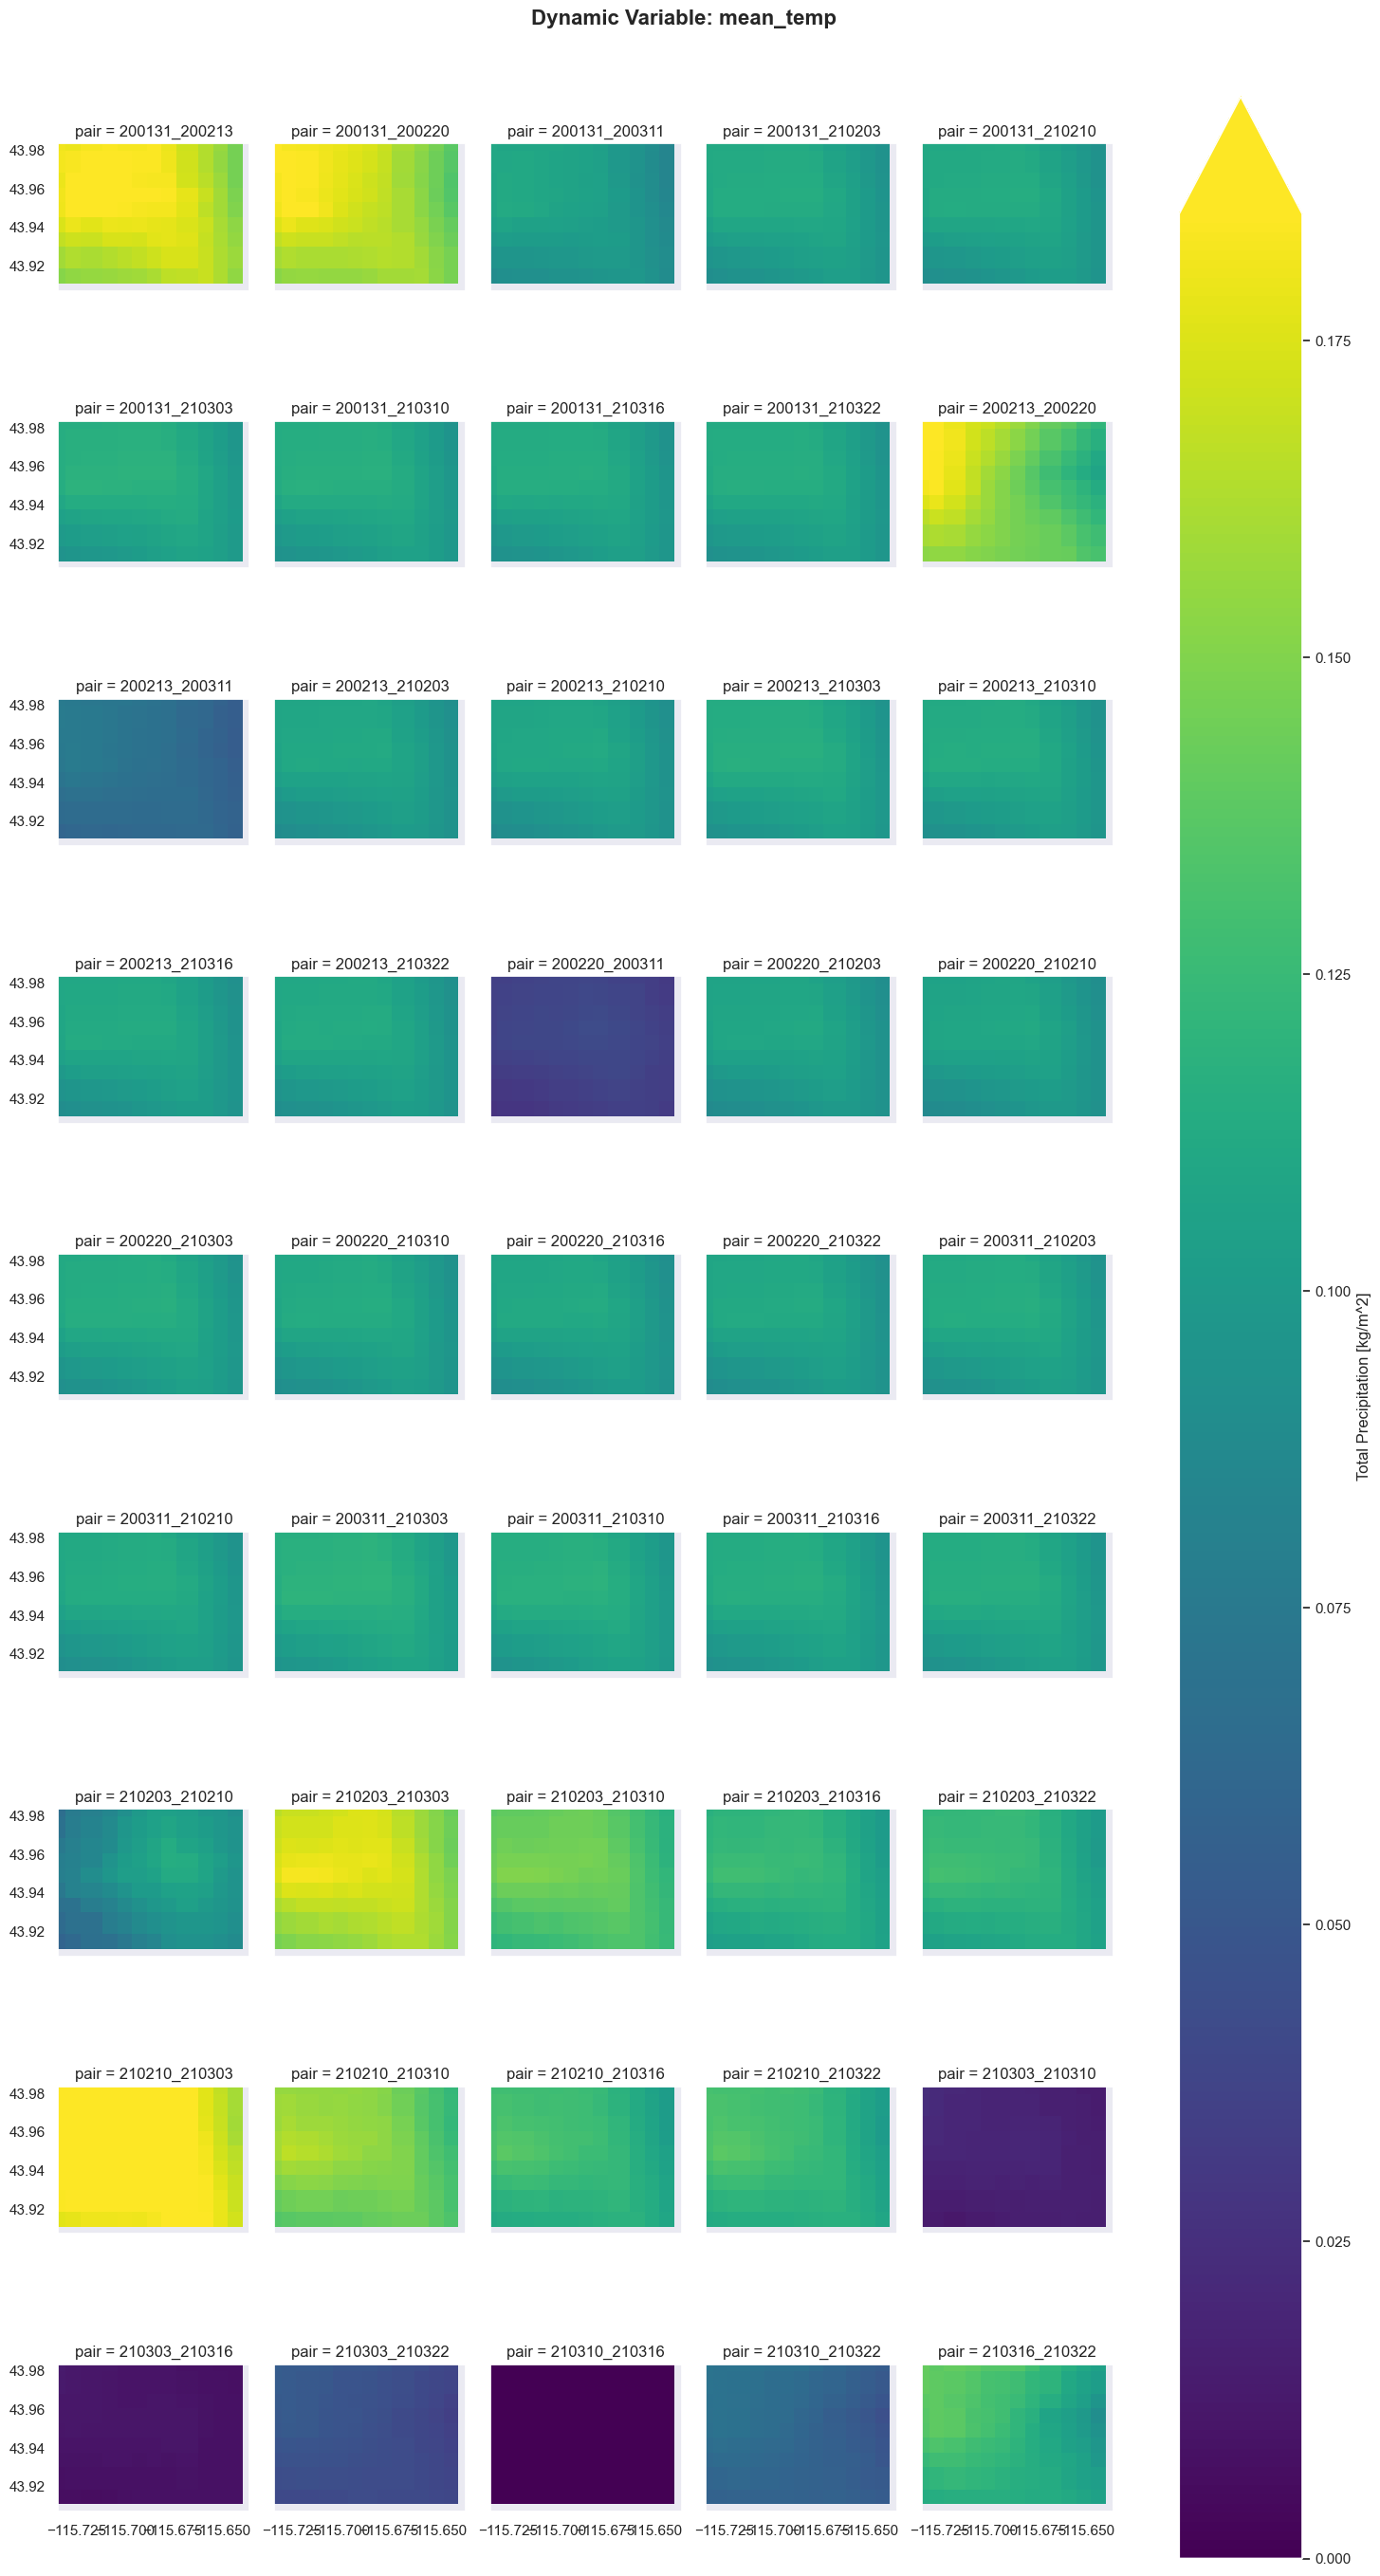

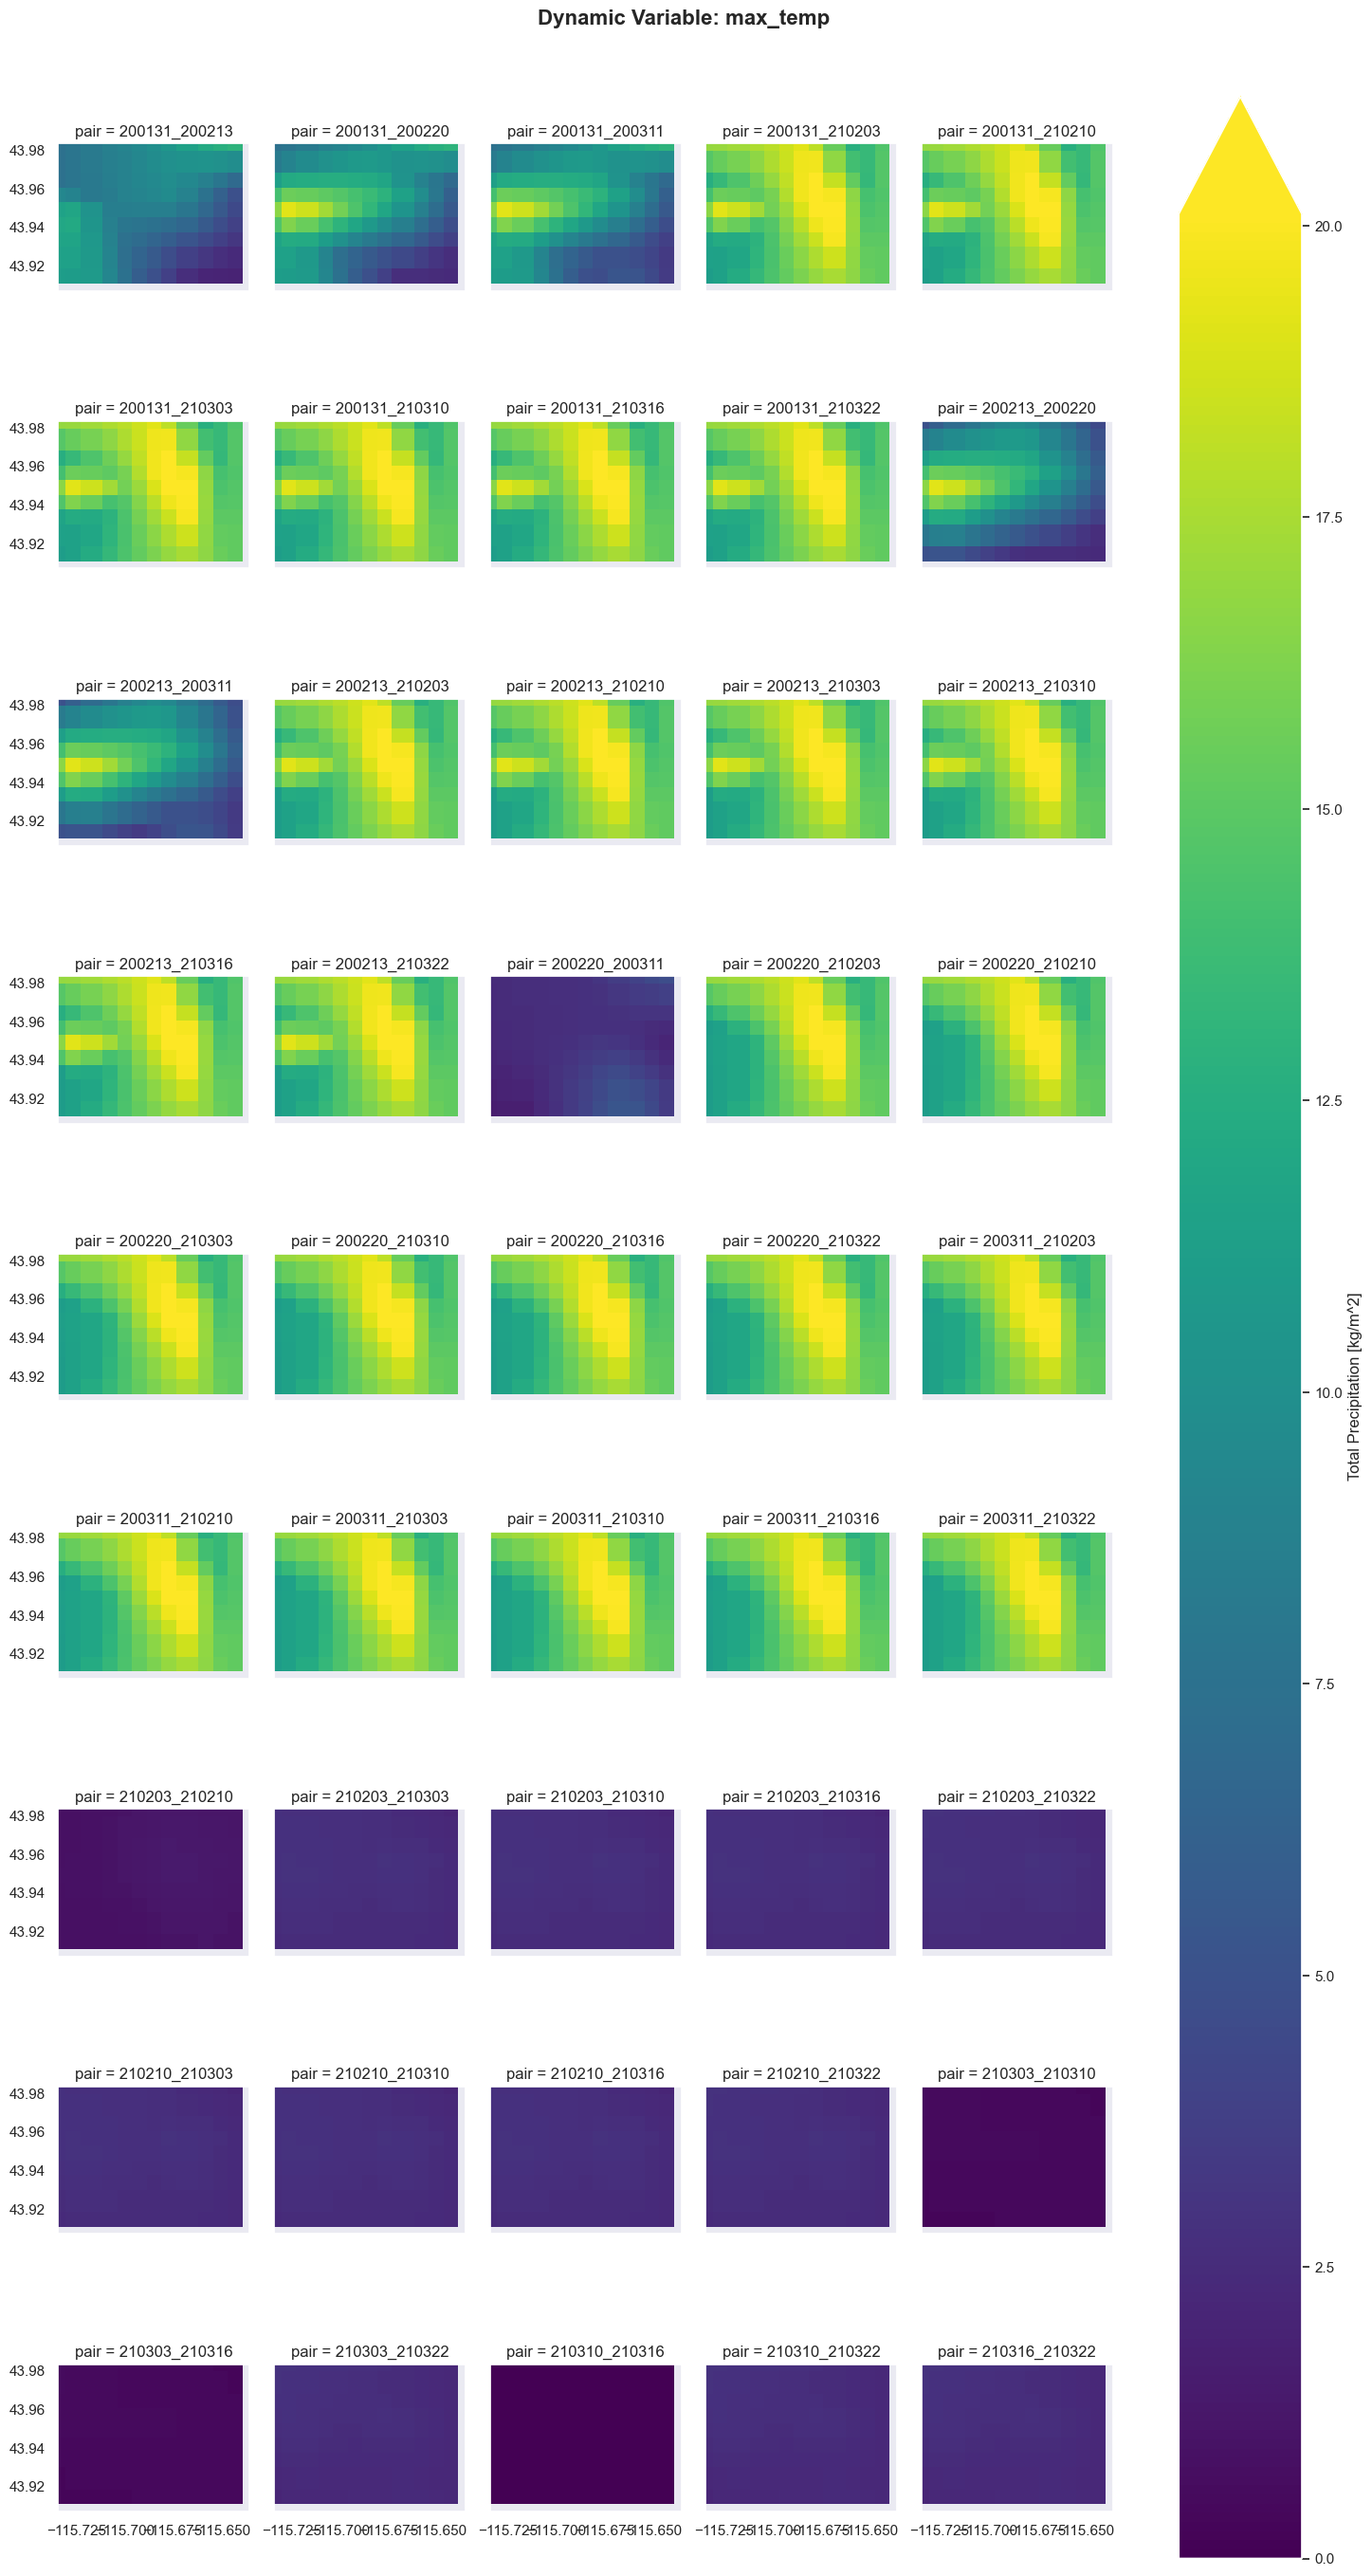

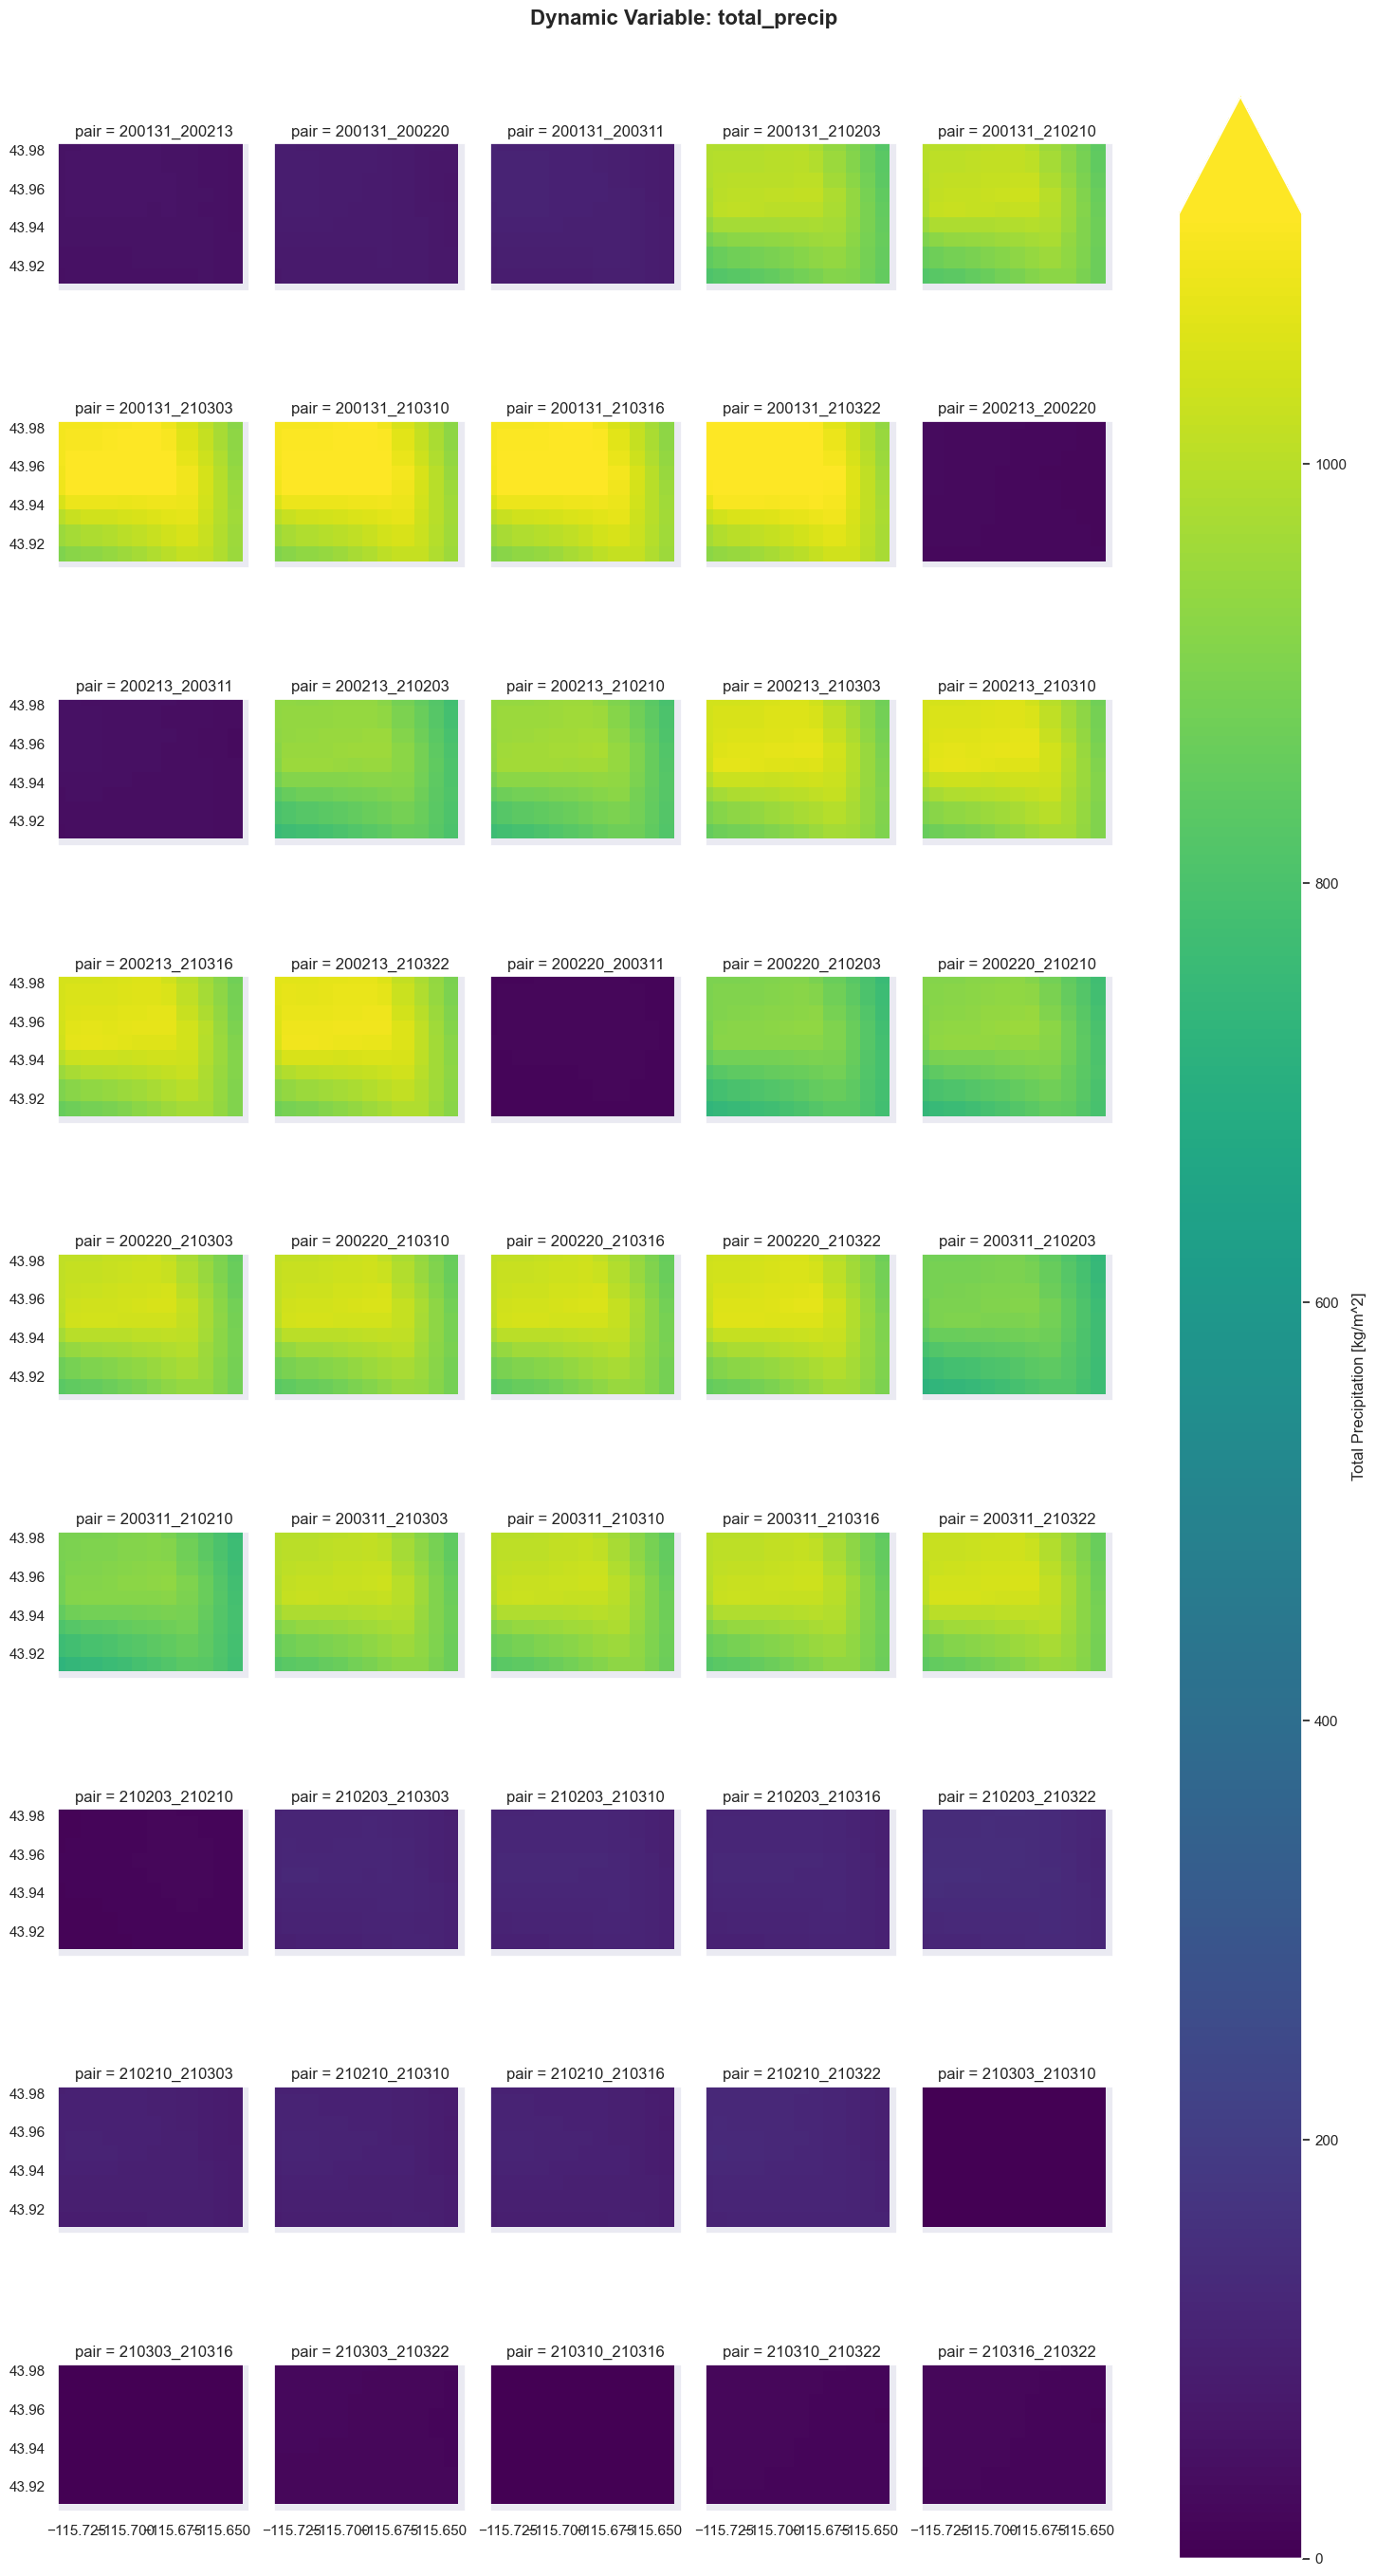

In [18]:
# plot the variables

# 1. Separate variables into two lists based on their dimensions
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

# Create one figure for all static variables
fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap='viridis') 
    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. PLOT DYNAMIC VARIABLES (One Figure Each)
# ==========================================
for var in pair_vars:
    # Pick a diverging colormap for 'change' variables, standard for others
    cmap = 'RdBu' if 'change' in var else 'viridis'
    
    # Xarray automatically creates a multi-panel figure when you use col=
    fg = data[var].plot(
        col='pair',
        col_wrap=5,  # 5 plots per row looks nice for 45 pairs
        figsize=(15, 3 * int(np.ceil(data.sizes['pair'] / 5))),
        robust=True,
        cmap=cmap
    )
    
    # Add a main title for this specific variable's figure
    fg.fig.suptitle(f'Dynamic Variable: {var}', fontsize=16, fontweight='bold', y=1.02)
    
    # Clean up the individual axes
    for ax in fg.axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal')
        
    plt.show()